In [7]:
!pip install --upgrade imbalanced-learn
!pip install --upgrade scikit-learn

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE  # to handle imbalance

In [9]:
df = pd.read_excel("glass.xlsx",sheet_name=1)

In [10]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [11]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [12]:

df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [ ]:
df.describe()

In [26]:
df.duplicated().sum()

np.int64(1)

In [27]:
df.drop_duplicates()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.29,72.61,0.08,9.18,0.0,0.0,6.0
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,0.0,0.0,6.0
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,0.0,0.0,6.0
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,0.0,0.0,6.0


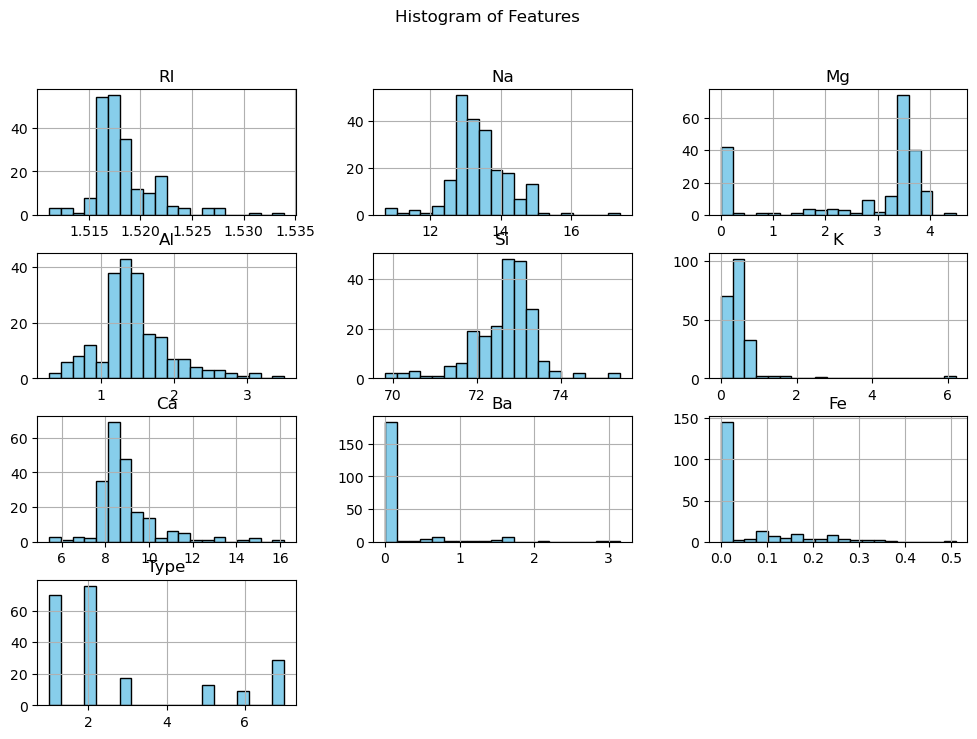

In [ ]:
# Data Visualization
df.hist(figsize=(12, 8), bins=20, color="skyblue", edgecolor="black")
plt.suptitle("Histogram of Features")
plt.show()

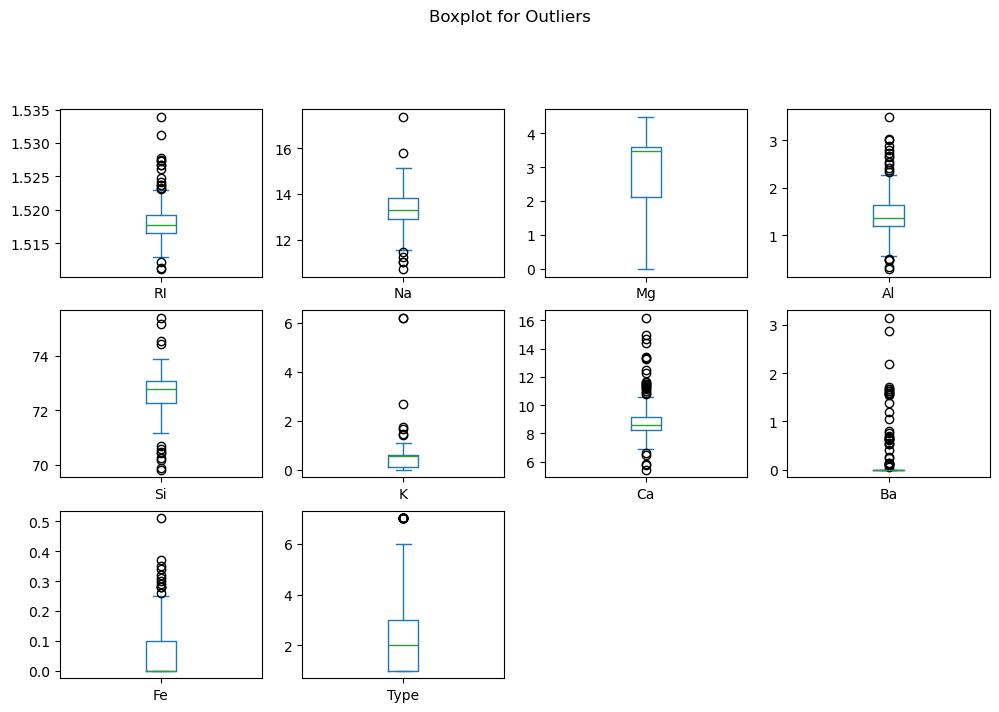

In [15]:
df.plot(kind="box", subplots=True, layout=(4,4), figsize=(12,10))
plt.suptitle("Boxplot for Outliers")
plt.show()

In [16]:
def outlier_capping(df,column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    lower_extreme=Q1-1.5*IQR
    upper_extreme=Q3+1.5*IQR
    df[column]=df[column].apply(lambda x:lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df.select_dtypes(['int','float']).columns:
    outlier_capping(df,col)

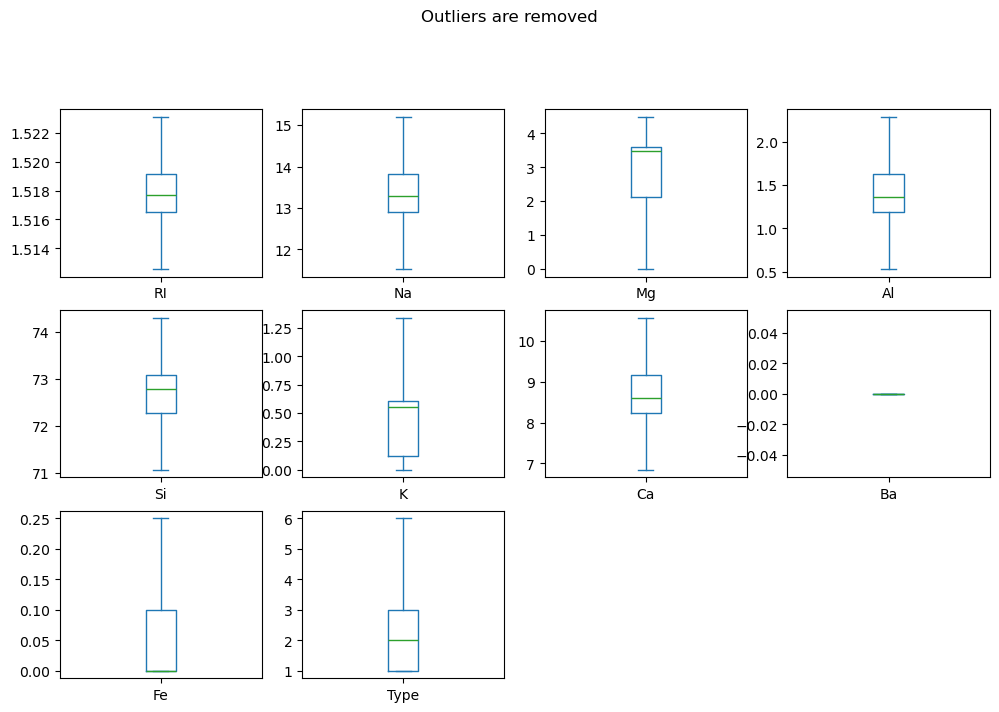

In [17]:
df.plot(kind="box", subplots=True, layout=(4,4), figsize=(12,10))
plt.suptitle("Outliers are removed")
plt.show()

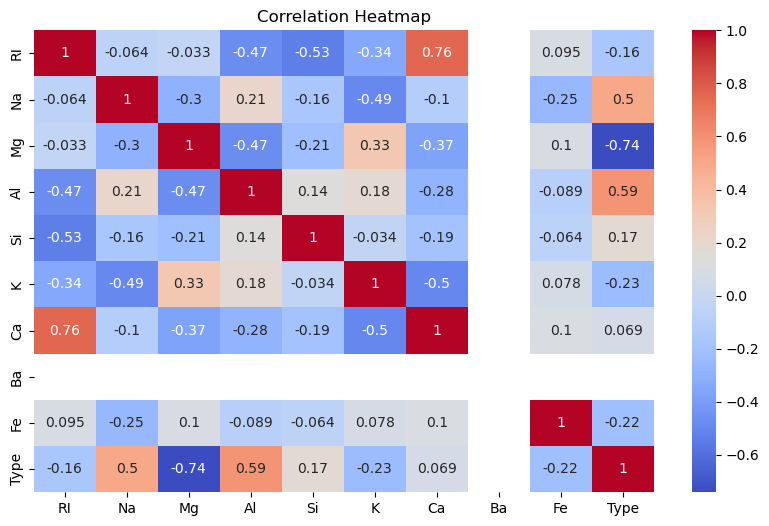

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

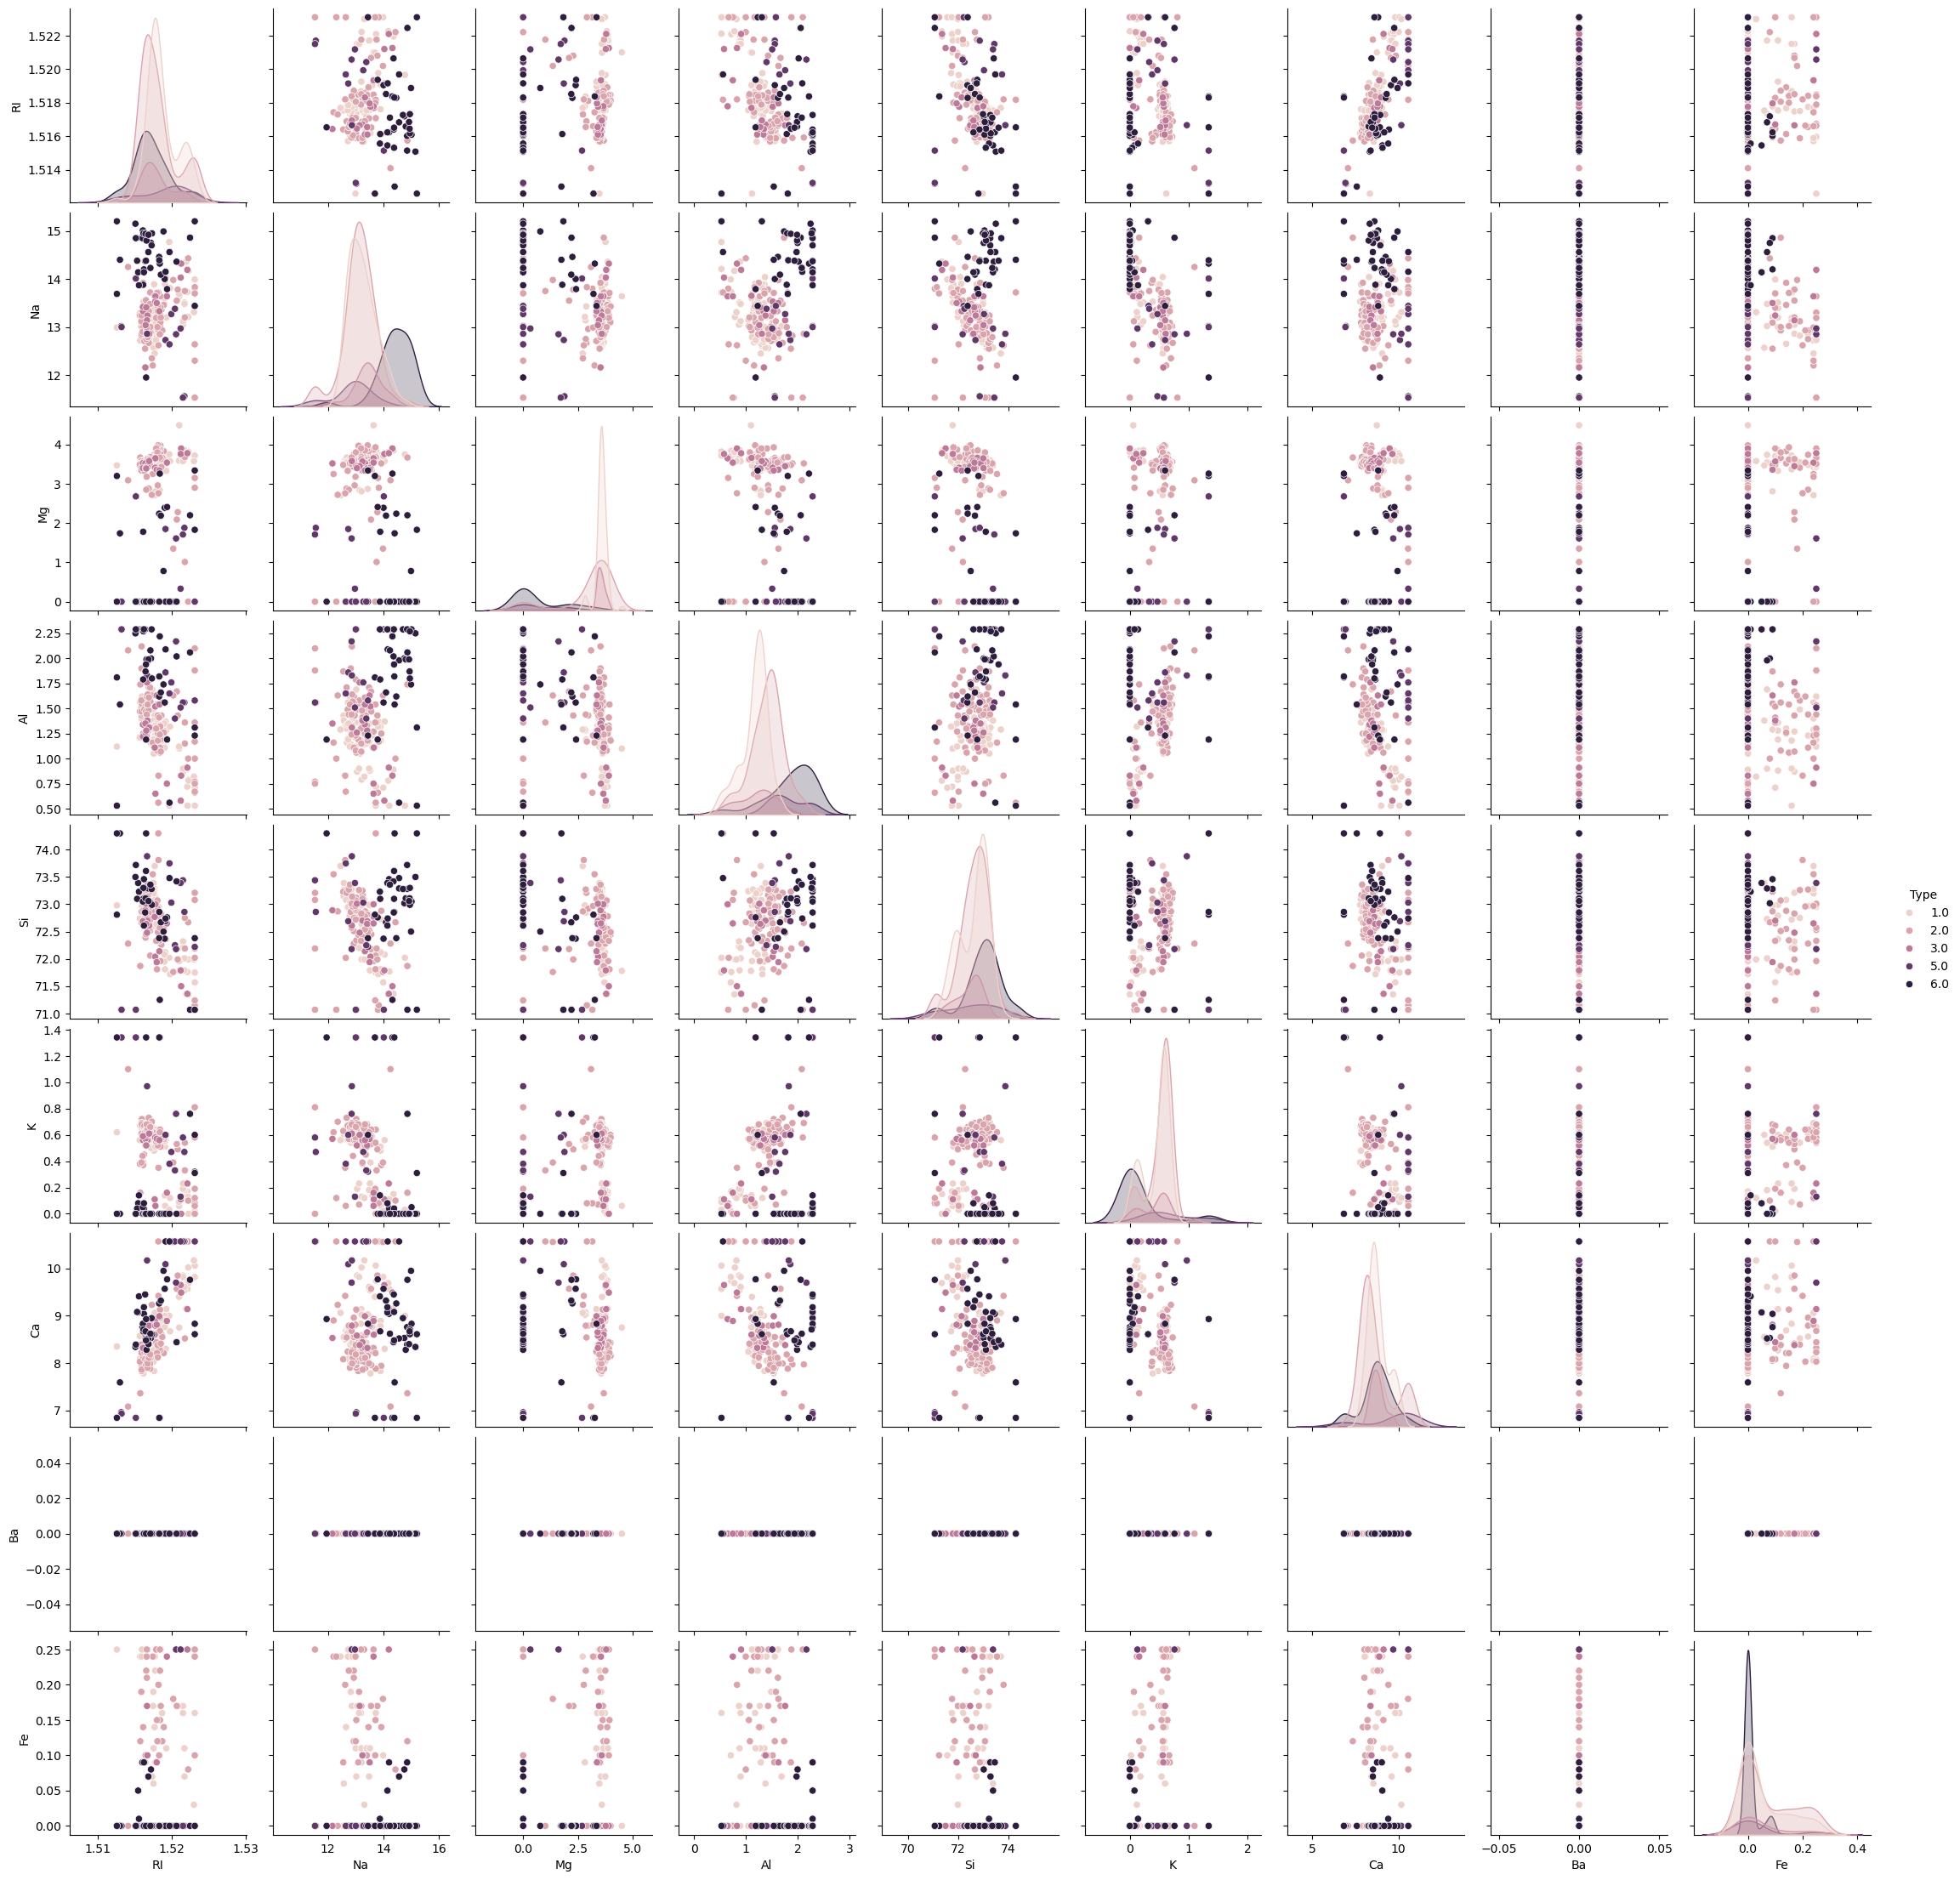

In [19]:
sns.pairplot(df, hue=df.columns[-1])
plt.show()

In [47]:
#  Data Preprocessing
target= df.columns[-1]  
target

'Type'

In [48]:
feature= df.iloc[:-1]
feature

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
208,1.51640,14.37,0.00,2.29,72.85,0.00,9.45,0.0,0.0,6.0
209,1.51623,14.14,0.00,2.29,72.61,0.08,9.18,0.0,0.0,6.0
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,0.0,0.0,6.0
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,0.0,0.0,6.0


In [ ]:
X = df.drop(columns=['Type'])  # 'Type' is target in Glass dataset
y = df['Type']

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [58]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)


In [59]:
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)


In [62]:
# Random Forest Classifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

In [63]:
print("\n Random Forest Performance")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


 Random Forest Performance
Accuracy: 0.813953488372093
Precision: 0.839543692741367
Recall: 0.813953488372093
F1 Score: 0.8053806688387073

Classification Report:
               precision    recall  f1-score   support

         1.0       0.69      1.00      0.81        11
         2.0       0.82      0.64      0.72        14
         3.0       1.00      0.67      0.80         3
         5.0       1.00      0.50      0.67         4
         6.0       0.92      1.00      0.96        11

    accuracy                           0.81        43
   macro avg       0.88      0.76      0.79        43
weighted avg       0.84      0.81      0.81        43



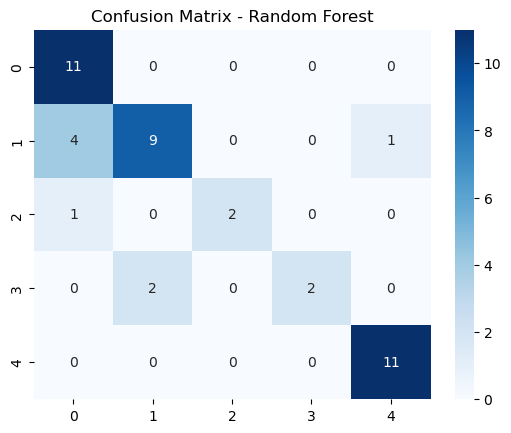

In [64]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix - Random Forest")
plt.show()

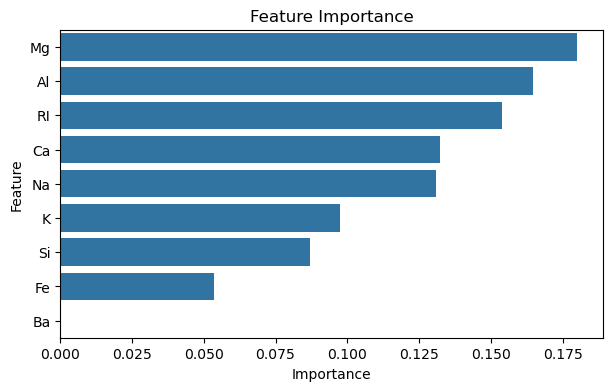

In [65]:
# Feature Importance Plot
feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(7,4))
sns.barplot(x="Importance", y="Feature", data=feat_imp)
plt.title("Feature Importance")
plt.show()

In [66]:
from sklearn.tree import DecisionTreeClassifier
bag_model = BaggingClassifier(DecisionTreeClassifier(), n_estimators=100, random_state=42)
bag_model.fit(X_train, y_train)
bag_pred = bag_model.predict(X_test)

In [68]:
print("\n Bagging Results")
print("Accuracy:", accuracy_score(y_test, bag_pred))


 Bagging Results
Accuracy: 0.7906976744186046


In [70]:
boost_model = GradientBoostingClassifier(random_state=42)
boost_model.fit(X_train, y_train)
boost_pred = boost_model.predict(X_test)

print("\nBoosting Results")
print("Accuracy:", accuracy_score(y_test, boost_pred))


Boosting Results
Accuracy: 0.9069767441860465


## 1. Bagging and Boosting 

### Bagging (Bootstrap Aggregation):
Bagging builds multiple models in parallel using random samples of the data. Each model learns independently, and their results are combined (majority vote or averaging). Bagging mainly reduces variance and helps prevent overfitting.
Example: Random Forest

### Boosting:
Boosting builds models sequentially. Each new model focuses on correcting the mistakes of the previous ones by giving higher weight to misclassified samples. Boosting reduces bias and improves model accuracy.
Examples: AdaBoost, Gradient Boosting, XGBoost

### Difference:

Bagging trains models independently, while boosting trains models one after another.

Bagging reduces variance, boosting reduces bias.

Bagging treats all samples equally; boosting focuses on difficult samples.

## 2. Handling Imbalance in the Data

Imbalanced data means one class has much fewer samples than the other (e.g., fraud vs. normal transactions). This can make models biased toward the majority class.

Ways to handle imbalance:

Oversampling minority class (e.g., SMOTE)

Undersampling majority class

Using class weights to penalize wrong predictions on minority class

Choosing proper metrics like Recall, F1-score, and ROC-AUC instead of accuracy

Goal:
Ensure the model learns equally from both majority and minority classes, improving fairness and prediction performance.